#### **Introduction**

Sales & Marketing department plays a key role in driving the company's sales and revenue growth. By analyzing historical sales transaction data, the company can uncover patterns in customer purchasing behavior that help identify opportunities to improve product promotion, optimize campaign timing, and focus efforts on high-performing markets.

#### **Business Questions**
##### Main Question:
What insights from the sales data can help the Sales and Marketing teams increase overall sales?

##### Sub Questions:
1. Which products generate the highest revenue?
2. What are the monthly and seasonal sales trends?
3. Which regions contribute the most to total sales?
4. Which product combinations are frequently purchased together?

#### **Data Source**
The dataset used in this analysis was obtained from Kaggle. It is publicly available and intended for exploratory data analysis practice.

Dataset: **Practice EDA on this Sales Dataset** by Dhruv Kothari  
Source: https://www.kaggle.com/datasets/dhruvkothari19/practice-eda-on-this-sales-dataset

#### **Data Overview**
This dataset contains sales transaction records including product information, quantity ordered, item price, order date and time, and customer location details such as street, city, state, and zip code.

##### **Import Library & Read Data**

In [1]:
import pandas as pd

df = pd.read_csv('sales_all_clean.csv')

df.head(10)

,order_id,product,quantity_ordered,price_each,order_date,order_month,order_quarter,order_time,street,city,state,zip
0,176558,USB-C Charging Cable,2,11.95,2019-04-19,4,Q2,08:46,917 1st St,Dallas,TX,75001
1,176559,Bose SoundSport Headphones,1,99.99,2019-04-07,4,Q2,22:30,682 Chestnut St,Boston,MA,2215
2,176560,Google Phone,1,600.00,2019-04-12,4,Q2,14:38,669 Spruce St,Los Angeles,CA,90001
3,176561,Wired Headphones,1,11.99,2019-04-30,4,Q2,09:27,333 8th St,Los Angeles,CA,90001
4,176562,USB-C Charging Cable,1,11.95,2019-04-29,4,Q2,13:03,381 Wilson St,San Francisco,CA,94016
5,176563,Bose SoundSport Headphones,1,99.99,2019-04-02,4,Q2,07:46,668 Center St,Seattle,WA,98101
6,176564,USB-C Charging Cable,1,11.95,2019-04-12,4,Q2,10:58,790 Ridge St,Atlanta,GA,30301
7,176565,Macbook Pro Laptop,1,1700.00,2019-04-24,4,Q2,10:38,915 Willow St,San Francisco,CA,94016
8,176566,Wired Headphones,1,11.99,2019-04-08,4,Q2,14:05,83 7th St,Boston,MA,2215
9,176567,Google Phone,1,600.00,2019-04-18,4,Q2,17:18,444 7th St,Los Angeles,CA,90001


#### **Graph Styling**

In [2]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

def set_chart_style(font='Arial', title_size=16, label_size=14, tick_size=12):
    sns.set_style("white")
    plt.rcParams['font.family'] = font
    plt.rcParams['axes.titlesize'] = title_size
    plt.rcParams['axes.labelsize'] = label_size
    plt.rcParams['xtick.labelsize'] = tick_size
    plt.rcParams['ytick.labelsize'] = tick_size
    plt.rcParams['axes.titleweight'] = 'bold'

#### **Exploratory Data Analysis** 

##### Which top 10 products generate the highest revenue?

To answer this question, we need to calculate the total revenue first.

In [3]:
df['revenue'] = df['quantity_ordered'] * df['price_each']

df = df[['order_id', 'product', 'quantity_ordered', 'price_each', 'revenue', 'order_date', 'order_month', 'order_quarter', 'order_time', 'street', 'city', 'state', 'zip']]

df

,order_id,product,quantity_ordered,price_each,revenue,order_date,order_month,order_quarter,order_time,street,city,state,zip
0,176558,USB-C Charging Cable,2,11.95,23.90,2019-04-19,4,Q2,08:46,917 1st St,Dallas,TX,75001
1,176559,Bose SoundSport Headphones,1,99.99,99.99,2019-04-07,4,Q2,22:30,682 Chestnut St,Boston,MA,2215
2,176560,Google Phone,1,600.00,600.00,2019-04-12,4,Q2,14:38,669 Spruce St,Los Angeles,CA,90001
3,176561,Wired Headphones,1,11.99,11.99,2019-04-30,4,Q2,09:27,333 8th St,Los Angeles,CA,90001
4,176562,USB-C Charging Cable,1,11.95,11.95,2019-04-29,4,Q2,13:03,381 Wilson St,San Francisco,CA,94016
...,...,...,...,...,...,...,...,...,...,...,...,...,...
178432,259353,AAA Batteries (4-pack),3,2.99,8.97,2019-09-17,9,Q3,20:56,840 Highland St,Los Angeles,CA,90001
178433,259354,iPhone,1,700.00,700.00,2019-09-01,9,Q3,16:00,216 Dogwood St,San Francisco,CA,94016
178434,259355,iPhone,1,700.00,700.00,2019-09-23,9,Q3,07:39,220 12th St,San Francisco,CA,94016
178435,259356,34in Ultrawide Monitor,1,379.99,379.99,2019-09-19,9,Q3,17:30,511 Forest St,San Francisco,CA,94016


Then, for the visualization:

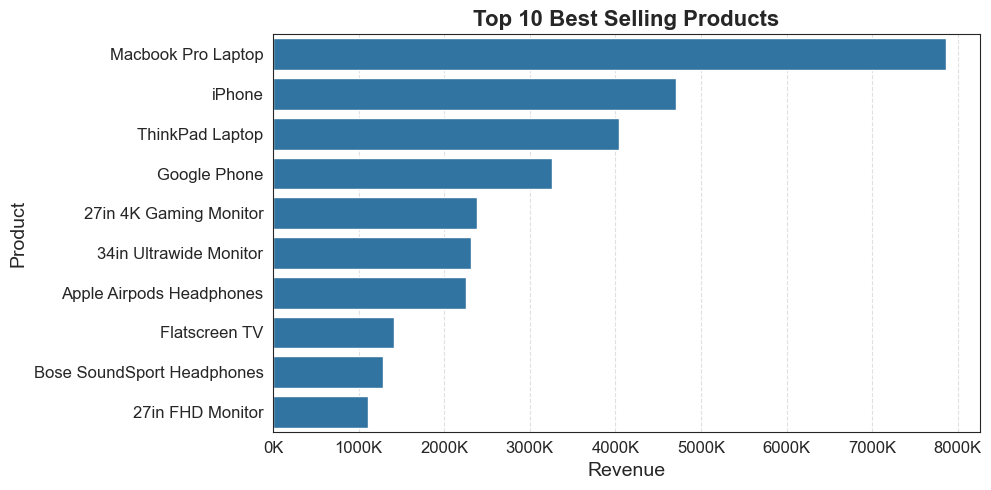

In [ ]:
top_products = (df.groupby('product')['revenue'] 
                .sum() 
                .sort_values(ascending=False) 
                .head(10)
)

top_products_df = top_products.reset_index()
top_products_df.columns = ['Product', 'Revenue']

set_chart_style(font='Arial')
plt.figure(figsize=(10,5))
ax = sns.barplot(
    data=top_products_df,
    y='Product',
    x='Revenue',
    orient='h'
)

plt.title('Top 10 Best Selling Products')
plt.xlabel('Revenue')
plt.ylabel('Product')
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, pos: f'{int(x/1000)}K'))

ax.grid(axis='x', linestyle='--', alpha=0.6)
ax.grid(axis='y', visible=False)
plt.tight_layout()
plt.show()

Among the top 10 products, **MacBook Pro Laptop** generates significantly more revenue than the others, highlighting its dominant position. The X-axis shows revenue in K USD, while the Y-axis lists product names.

#### Which product combinations are frequently purchased together?

In [ ]:
# graph

Graph Explanation

#### What are the monthly and seasonal sales trends?

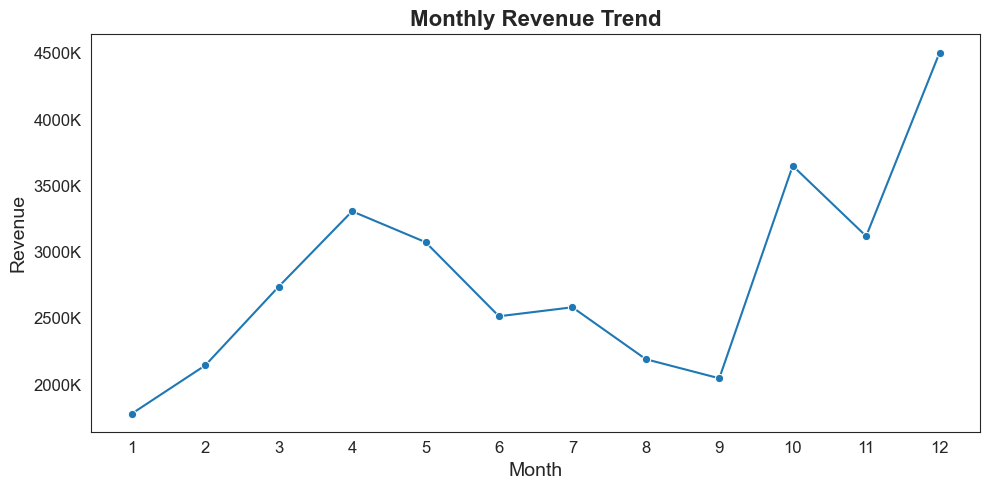

In [ ]:
revenue_month = df.groupby('order_month')['revenue'].sum().reset_index()

plt.figure(figsize=(10,5))
ax = sns.lineplot(data=revenue_month, x='order_month', y='revenue', marker='o')

plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')

plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{int(x/1000)}K'))

plt.xticks(range(1,13))
plt.tight_layout()
plt.show()

From the graph above, the monthly revenue trend peaks in December. Revenue gradually declines from April over the following months before rising again in October. January records the lowest revenue, reflecting the post-holiday slow period.

#### Which regions contribute the most to total revenue?

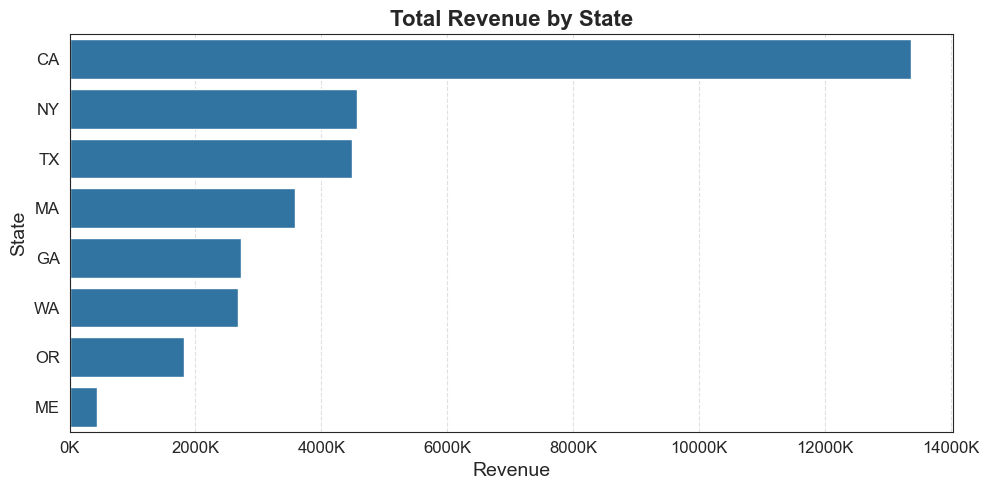

In [37]:
state_revenue = (df.groupby('state')['revenue'] 
                .sum() 
                .sort_values(ascending=False)
            )

state_revenue_df = state_revenue.reset_index()
state_revenue_df.columns = ['State', 'Revenue']

set_chart_style(font='Arial')
plt.figure(figsize=(10,5))
ax = sns.barplot(
    data=state_revenue_df,
    x='Revenue',
    y='State'    
)

plt.title('Total Revenue by State')
plt.xlabel('Revenue')
plt.ylabel('State')

ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, pos: f'{int(x/1000)}K'))
ax.grid(axis='x', linestyle='--', alpha=0.6)
ax.grid(axis='y', visible=False)

plt.tight_layout()
plt.show()

Among all states, California (CA) generates significantly higher revenue compared to other states, indicating it is the dominant market. Other states follow, but there is a noticeable gap.

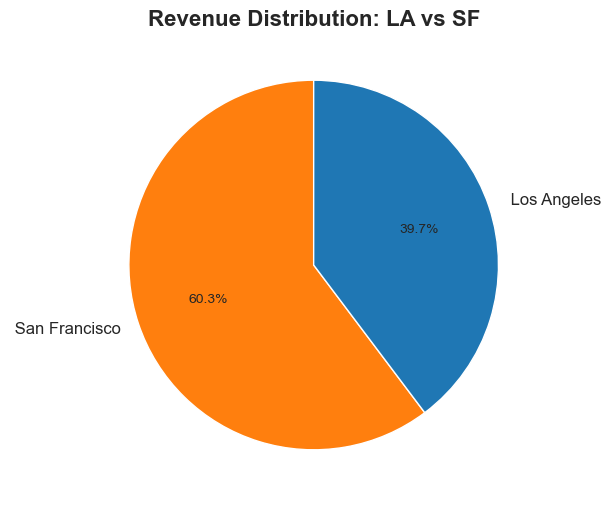

In [63]:
df_ca = df[df['state'].str.contains('CA', na=False)]

city_revenue_ca = df_ca.groupby('city')['revenue'].sum().sort_values(ascending=False)

set_chart_style(font='Arial')
plt.figure(figsize=(6,6))
colors = ['tab:orange', 'tab:blue']
plt.pie(
    city_revenue_ca,
    labels=city_revenue_ca.index,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    wedgeprops={'edgecolor': 'white'}
)
plt.title('Revenue Distribution: LA vs SF')
plt.show()

**San Francisco** dominates revenue in California, contributing 60.3% of the combined total of the top two cities, while Los Angeles accounts for 39.7%.

#### **Key Insights**

1. **MacBook Pro Laptop** generates significantly higher revenue than other products, indicating strong customer preference. **iPhone** and **ThinkPad Laptop** follow but with a noticeable gap, suggesting opportunity to boost mid-tier product sales.
2. 
3. **December is the peak month**, with the highest revenue, while **January records the lowest revenue**, and revenue gradually declines from April before rising again in October.
4. **California leads overall revenue**, with **San Francisco** contributing **60.3%** of the total revenue between the two cities, and Los Angeles making up the remaining 39.7%.

(ini pake poin2 aja)

#### **Conclusion**

(1 paragraf singkat aja)